In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("vitamin_deficiency_disease_dataset.csv")
df

,age,gender,bmi,smoking_status,alcohol_consumption,exercise_level,diet_type,sun_exposure,income_level,latitude_region,...,has_night_blindness,has_fatigue,has_bleeding_gums,has_bone_pain,has_muscle_weakness,has_numbness_tingling,has_memory_problems,has_pale_skin,disease_diagnosis,has_multiple_deficiencies
0,79,Male,24.8,Former,NaN,Active,Vegetarian,High,High,Mid,...,0,0,0,0,0,0,0,0,Healthy,0
1,77,Female,39.9,Former,Moderate,Light,Omnivore,Low,Low,Low,...,0,0,0,1,0,0,0,0,Rickets_Osteomalacia,0
2,24,Male,26.4,Former,Heavy,Moderate,Omnivore,Low,High,High,...,1,0,0,0,0,0,0,0,Healthy,0
3,69,Male,23.1,Never,Heavy,Moderate,Vegetarian,High,Low,Low,...,0,0,0,0,0,1,1,0,Anemia,0
4,63,Male,29.6,Never,NaN,Moderate,Vegetarian,Moderate,High,Low,...,0,0,0,0,0,0,0,0,Healthy,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,25,Female,21.6,Former,Heavy,Active,Pescatarian,Moderate,Middle,High,...,1,0,0,0,0,0,0,0,Healthy,0
3996,50,Male,29.5,Former,Moderate,Sedentary,Vegetarian,Low,High,Low,...,0,0,0,0,0,0,0,0,Healthy,0
3997,34,Female,24.8,Never,NaN,Active,Pescatarian,Moderate,Low,Low,...,0,1,0,0,0,1,1,0,Anemia,0
3998,39,Female,26.9,Former,Heavy,Active,Omnivore,High,Low,High,...,1,0,0,0,0,0,0,0,Anemia,0


In [3]:
df = df.drop('symptoms_list', axis=1)  # Remove this column because symptoms are already given in other columns

In [4]:
df

,age,gender,bmi,smoking_status,alcohol_consumption,exercise_level,diet_type,sun_exposure,income_level,latitude_region,...,has_night_blindness,has_fatigue,has_bleeding_gums,has_bone_pain,has_muscle_weakness,has_numbness_tingling,has_memory_problems,has_pale_skin,disease_diagnosis,has_multiple_deficiencies
0,79,Male,24.8,Former,NaN,Active,Vegetarian,High,High,Mid,...,0,0,0,0,0,0,0,0,Healthy,0
1,77,Female,39.9,Former,Moderate,Light,Omnivore,Low,Low,Low,...,0,0,0,1,0,0,0,0,Rickets_Osteomalacia,0
2,24,Male,26.4,Former,Heavy,Moderate,Omnivore,Low,High,High,...,1,0,0,0,0,0,0,0,Healthy,0
3,69,Male,23.1,Never,Heavy,Moderate,Vegetarian,High,Low,Low,...,0,0,0,0,0,1,1,0,Anemia,0
4,63,Male,29.6,Never,NaN,Moderate,Vegetarian,Moderate,High,Low,...,0,0,0,0,0,0,0,0,Healthy,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,25,Female,21.6,Former,Heavy,Active,Pescatarian,Moderate,Middle,High,...,1,0,0,0,0,0,0,0,Healthy,0
3996,50,Male,29.5,Former,Moderate,Sedentary,Vegetarian,Low,High,Low,...,0,0,0,0,0,0,0,0,Healthy,0
3997,34,Female,24.8,Never,NaN,Active,Pescatarian,Moderate,Low,Low,...,0,1,0,0,0,1,1,0,Anemia,0
3998,39,Female,26.9,Former,Heavy,Active,Omnivore,High,Low,High,...,1,0,0,0,0,0,0,0,Anemia,0


### Detect Outliers

# Exploratory Data Analysis

### 1. What is the frequency of each disease_diagnosis in the dataset?

Disease Frequency:

disease_diagnosis
Healthy                 1509
Anemia                  1245
Rickets_Osteomalacia    1029
Night_Blindness          122
Scurvy                    95
Name: count, dtype: int64


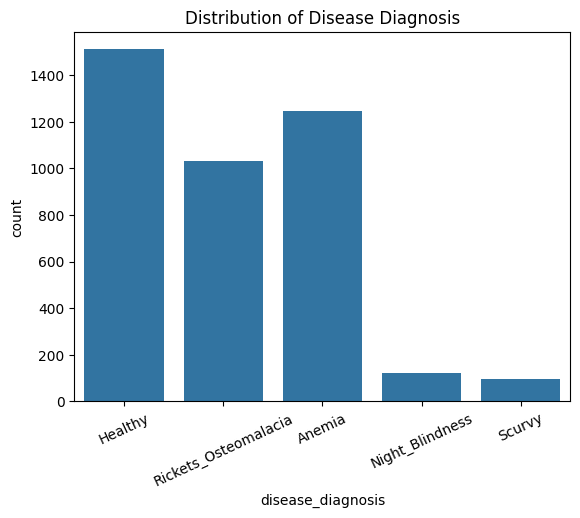

In [5]:
sns.countplot(x='disease_diagnosis', data=df)
# Print Frequency Table
disease_counts = df['disease_diagnosis'].value_counts()
print("Disease Frequency:\n")
print(disease_counts)
# Visualisation
plt.title("Distribution of Disease Diagnosis")
plt.xticks(rotation=25)   # Rotate labels
plt.show()


In [6]:
# The dataset contains more Healthy individuals compared to other diseases. Among the diseases, 
# Anemia and Rickets/Osteomalacia have higher counts, while Night Blindness and Scurvy have relatively fewer cases.

### 2. What are the average haemoglobin, iron, and serum folate levels for Anaemia vs Healthy individuals? 

In [7]:
 # Filter only needed classes
subset = df[df['disease_diagnosis'].isin(['Anemia', 'Healthy'])]

In [8]:
# Calculate Mean values
subset.groupby('disease_diagnosis')[[
    'hemoglobin_g_dl',
    'iron_percent_rda',
    'serum_folate_ng_ml'
]].mean()

,hemoglobin_g_dl,iron_percent_rda,serum_folate_ng_ml
disease_diagnosis,,,
Anemia,13.807711,64.011888,9.838635
Healthy,14.405302,98.196885,12.973691


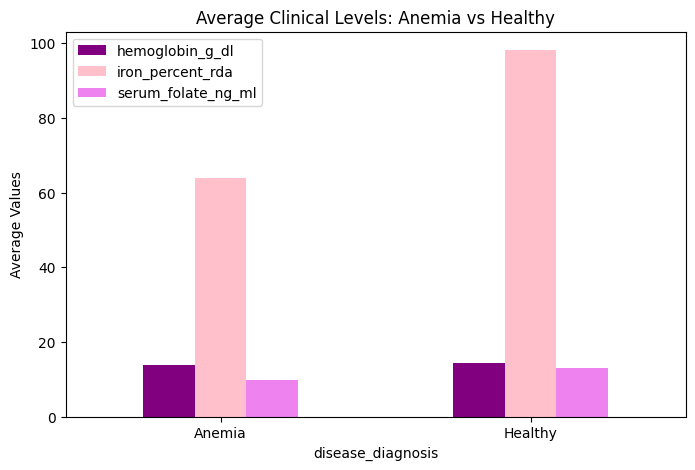

In [9]:
# Visualisation

subset.groupby('disease_diagnosis')[[
    'hemoglobin_g_dl',
    'iron_percent_rda',
    'serum_folate_ng_ml'
]].mean().plot(kind='bar', figsize=(8,5),color=['purple', 'pink', 'violet'])

plt.title("Average Clinical Levels: Anemia vs Healthy")
plt.xticks(rotation=0)
plt.ylabel("Average Values")
plt.show()

In [10]:
# Individuals with anemia have lower average hemoglobin, iron, and serum folate levels compared to healthy individuals. 
# This clearly indicates that deficiencies in these clinical markers are strongly associated with anemia.

### 3.	How do vitamin D and calcium levels differ between Rickets/Osteomalacia and Healthy individuals? 

C:\Users\hp\AppData\Local\Temp\ipykernel_17356\3784771652.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='disease_diagnosis', y='vitamin_d_percent_rda',
C:\Users\hp\AppData\Local\Temp\ipykernel_17356\3784771652.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='disease_diagnosis', y='calcium_percent_rda',


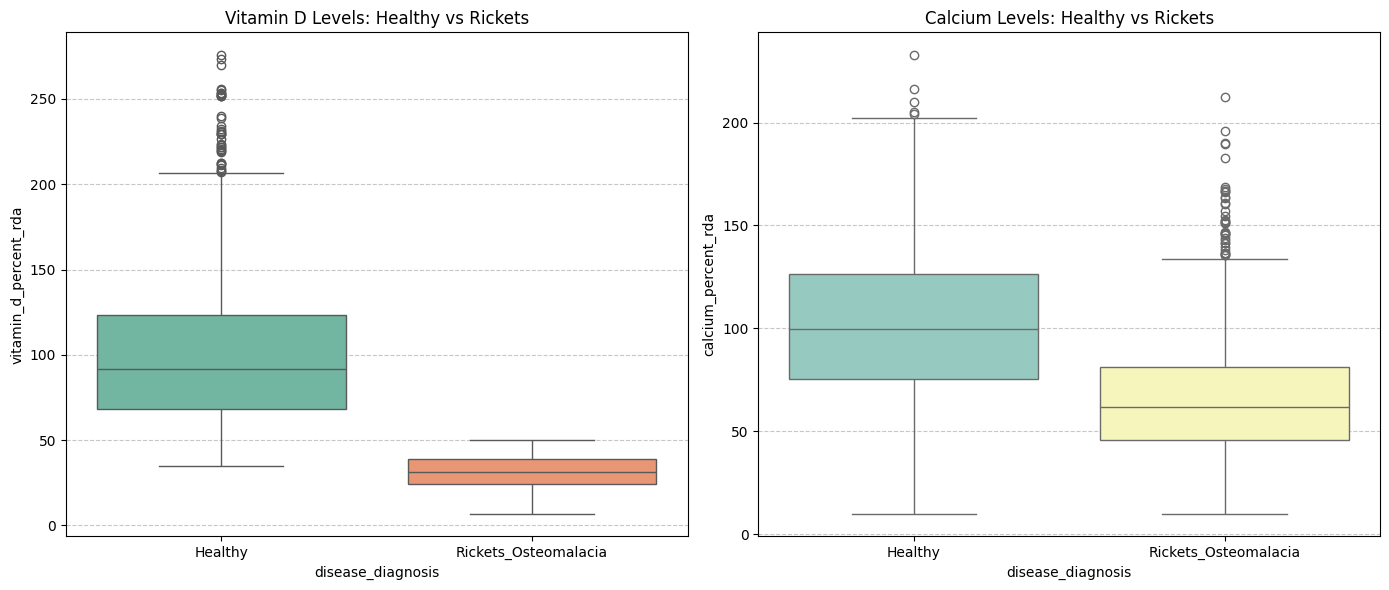

In [11]:
# Plotting Vitamin D and Calcium comparison for Rickets vs Healthy
plt.figure(figsize=(14, 6))

# Subplot 1: Vitamin D Comparison
plt.subplot(1, 2, 1)
sns.boxplot(x='disease_diagnosis', y='vitamin_d_percent_rda', 
            data=df[df['disease_diagnosis'].isin(['Healthy', 'Rickets_Osteomalacia'])],
            palette='Set2')
plt.title('Vitamin D Levels: Healthy vs Rickets')
plt.grid(axis='y', linestyle='--', alpha=0.7)
# Vitamin D Distribution: Healthy vs Rickets/Osteomalacia
# Calcium Distribution: Healthy vs Rickets/Osteomalacia
# Subplot 2: Calcium Comparison
plt.subplot(1, 2, 2)
sns.boxplot(x='disease_diagnosis', y='calcium_percent_rda', 
            data=df[df['disease_diagnosis'].isin(['Healthy', 'Rickets_Osteomalacia'])],
            palette='Set3')
plt.title('Calcium Levels: Healthy vs Rickets')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


In [12]:
# People with Rickets/Osteomalacia have much lower Vitamin D levels than healthy people. 
# Their Calcium levels are also lower, which shows that low Vitamin D and Calcium are important factors related to this disease

### 4.	Which symptoms are most common in each disease? 

In [13]:
# Identifying all symptom columns
symptom_cols = [col for col in df.columns if col.startswith('has_')]

In [14]:
# Grouping by diagnosis and calculating the mean (which gives the proportion/percentage)
symptom_dist = df.groupby('disease_diagnosis')[symptom_cols].mean()

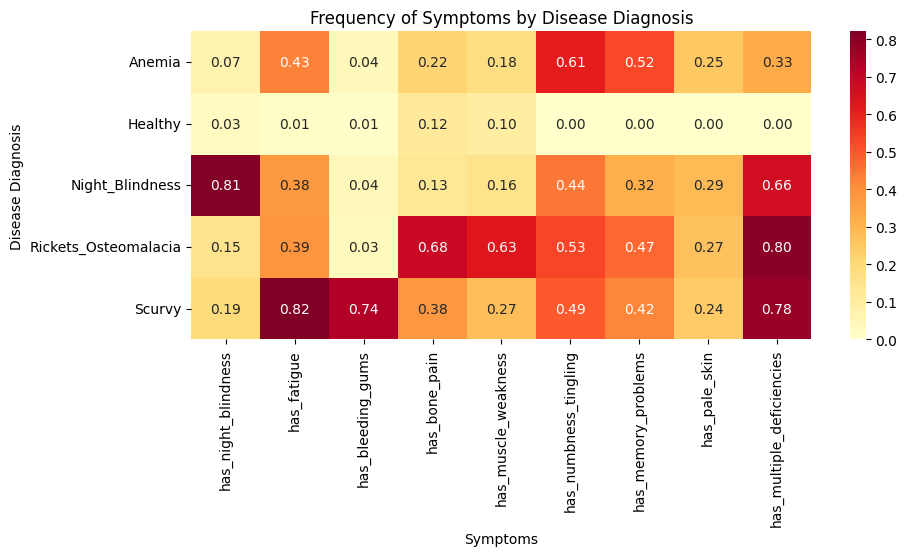

In [15]:
# Plotting the heatmap
plt.figure(figsize=(10, 4))
sns.heatmap(symptom_dist, annot=True, cmap='YlOrRd', fmt='.2f')
plt.title('Frequency of Symptoms by Disease Diagnosis')
plt.xlabel('Symptoms')
plt.ylabel('Disease Diagnosis')
plt.show()

In [16]:
# Individuals diagnosed with Rickets/Osteomalacia have significantly lower Vitamin D levels compared to healthy individuals.
# Similarly, calcium levels are also lower in affected individuals. This indicates that deficiencies in Vitamin D and 
# calcium are strongly associated with Rickets/Osteomalacia.

### 5. Which diet type has the highest number of Anemia cases? 

In [17]:
# Filter only Anemia patients
anemia_df = df[df['disease_diagnosis'] == 'Anemia']

# Count diet types
diet_counts = anemia_df['diet_type'].value_counts()

# Print Results
print("Diet Type Count among Anemia Patients:\n")
print(diet_counts)

Diet Type Count among Anemia Patients:

diet_type
Vegan          472
Vegetarian     327
Pescatarian    247
Omnivore       199
Name: count, dtype: int64


C:\Users\hp\AppData\Local\Temp\ipykernel_17356\3382014619.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=anemia_df,x='diet_type', order=anemia_df['diet_type'].value_counts().index,palette='Set2')


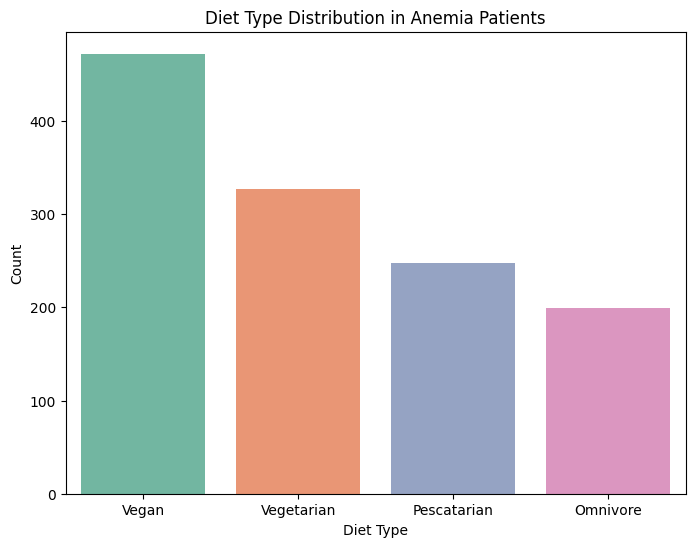

In [18]:
#  Visualization
plt.figure(figsize=(8,6))
sns.countplot(data=anemia_df,x='diet_type', order=anemia_df['diet_type'].value_counts().index,palette='Set2')
plt.title("Diet Type Distribution in Anemia Patients")
plt.xlabel("Diet Type")
plt.ylabel("Count")
plt.show()

In [19]:
# The graph shows that Anemia cases are highest among Vegan individuals followed by Vegetarians.
# Omnivores have the lowest number of Anemia cases. This shows that diet type may influence anemia risk especially in plant-based diets.

### 6.	How does sun exposure affect Vitamin D levels? 

In [20]:
# Groupby sun exposure
sun_vitd = df.groupby('sun_exposure')['serum_vitamin_d_ng_ml'].mean().reset_index()

# Print Mean Comparison
print("\nAverage Serum Vitamin D by Sun Exposure:\n")
print(sun_vitd)




Average Serum Vitamin D by Sun Exposure:

  sun_exposure  serum_vitamin_d_ng_ml
0         High              28.563855
1          Low              14.877414
2     Moderate              21.724097


C:\Users\hp\AppData\Local\Temp\ipykernel_17356\368033436.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


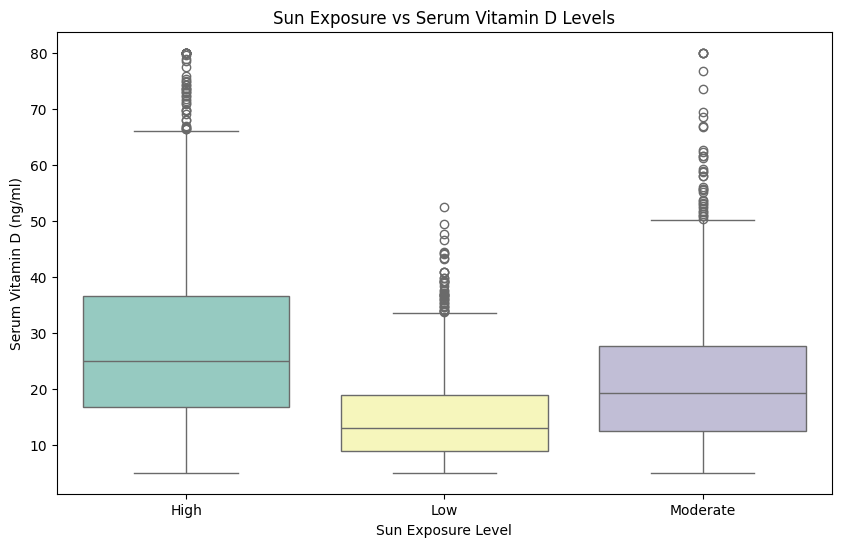

In [21]:
#  Visualization
plt.figure(figsize=(10,6))
sns.boxplot(
    data=df,
    x='sun_exposure',
    y='serum_vitamin_d_ng_ml',
    palette='Set3'
)

plt.title("Sun Exposure vs Serum Vitamin D Levels")
plt.xlabel("Sun Exposure Level")
plt.ylabel("Serum Vitamin D (ng/ml)")
plt.show()

In [22]:
# The graph shows that people with high sun exposure generally have higher serum Vitamin D levels, while low sun exposure
# have lower Vitamin D levels. This shows that increased sunlight exposure plays an important role in maintaining better Vitamin D levels.

### 7.	Does alcohol consumption affect disease diagnosis? 

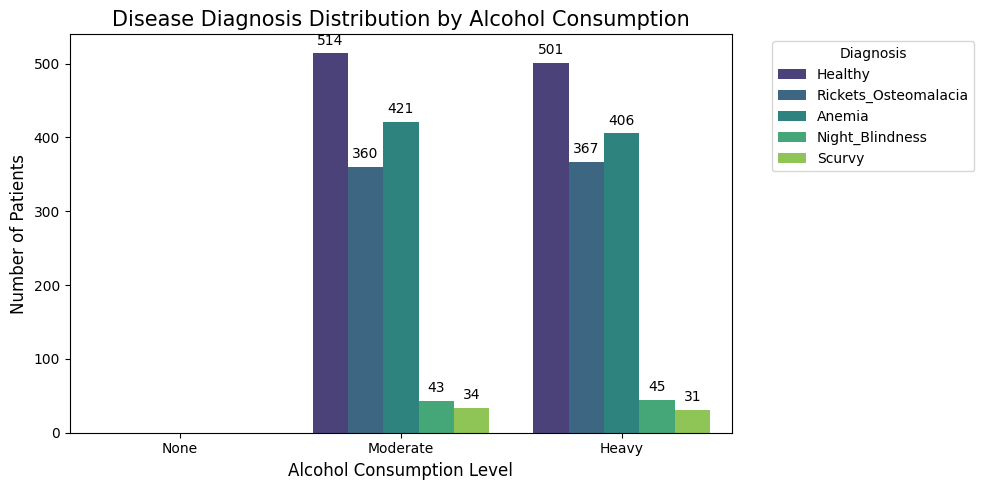

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Defining the logical order for alcohol consumption
alc_order = ['None', 'Moderate', 'Heavy']

plt.figure(figsize=(10, 5))

# Creating a count plot to see the frequency of each disease per alcohol level
ax = sns.countplot(x='alcohol_consumption', hue='disease_diagnosis', data=df, 
                   order=alc_order, palette='viridis')

plt.title('Disease Diagnosis Distribution by Alcohol Consumption', fontsize=15)
plt.xlabel('Alcohol Consumption Level', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)
plt.legend(title='Diagnosis', bbox_to_anchor=(1.05, 1), loc='upper left')

# Adding counts on top of bars
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{int(p.get_height())}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha = 'center', va = 'center', 
                    xytext = (0, 9), 
                    textcoords = 'offset points')

plt.tight_layout()
plt.show()

In [24]:
# Alcohol consumption shows only small differences across disease categories, with similar patterns between heavy and moderate drinkers. 
# This suggests that alcohol consumption alone may not strongly influence disease diagnosis in this dataset.

### 8. Does smoking status affect Vitamin C levels? 

In [25]:
# Groupby smoking status
smoking_vitc = df.groupby('smoking_status')['vitamin_c_percent_rda'].mean()

# Print Mean Values
print("\nAverage Vitamin C Levels by Smoking Status:\n")
print(smoking_vitc)



Average Vitamin C Levels by Smoking Status:

smoking_status
Current    89.377678
Former     89.949054
Never      88.284524
Name: vitamin_c_percent_rda, dtype: float64


C:\Users\hp\AppData\Local\Temp\ipykernel_17356\2084040278.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='smoking_status', y='vitamin_c_percent_rda', data=df,


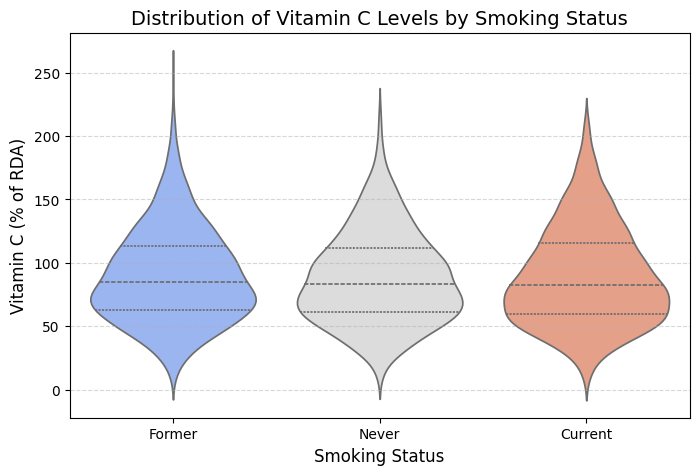

In [26]:
# Checking the Vitamin C distribution across Smoking Status
plt.figure(figsize=(8, 5))

# Using a violin plot to see the density of Vitamin C levels
sns.violinplot(x='smoking_status', y='vitamin_c_percent_rda', data=df, 
               palette='coolwarm', inner='quartile')

plt.title('Distribution of Vitamin C Levels by Smoking Status', fontsize=14)
plt.xlabel('Smoking Status', fontsize=12)
plt.ylabel('Vitamin C (% of RDA)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

In [27]:
# Vitamin C levels show only small differences across smoking groups. Current smokers appear to have slightly lower median Vitamin C levels
# compared to never and former smokers. This suggests smoking may have a mild negative effect on Vitamin C levels, 
# but the overall distributions are fairly similar.

### 9.	Does disease distribution differ between males and females? 

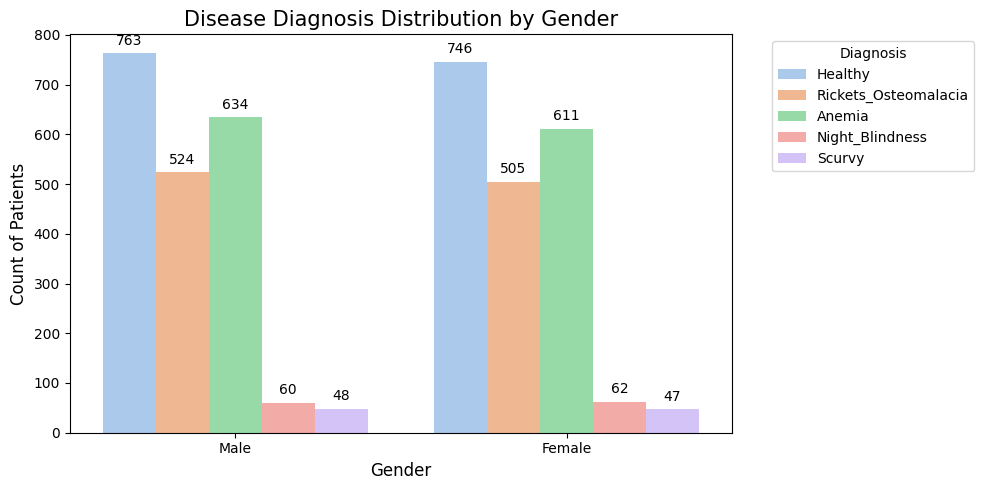

In [28]:
plt.figure(figsize=(10, 5))

# Creating a count plot to see the frequency of each disease per gender
ax = sns.countplot(x='gender', hue='disease_diagnosis', data=df, palette='pastel')

plt.title('Disease Diagnosis Distribution by Gender', fontsize=15)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Count of Patients', fontsize=12)
plt.legend(title='Diagnosis', bbox_to_anchor=(1.05, 1), loc='upper left')

# Adding data labels (counts) on top of each bar
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{int(p.get_height())}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha = 'center', va = 'center', 
                    xytext = (0, 9), 
                    textcoords = 'offset points')

plt.tight_layout()
plt.show()

In [29]:
# Disease distribution is fairly similar between males and females across all categories. 
# Both genders show the highest count in Healthy individuals, followed by Anemia and Rickets/Osteomalacia. 
# Males have slightly higher counts in most disease categories, but the overall pattern remains consistent for both genders.

###  10. Does income level affect disease occurrence? 

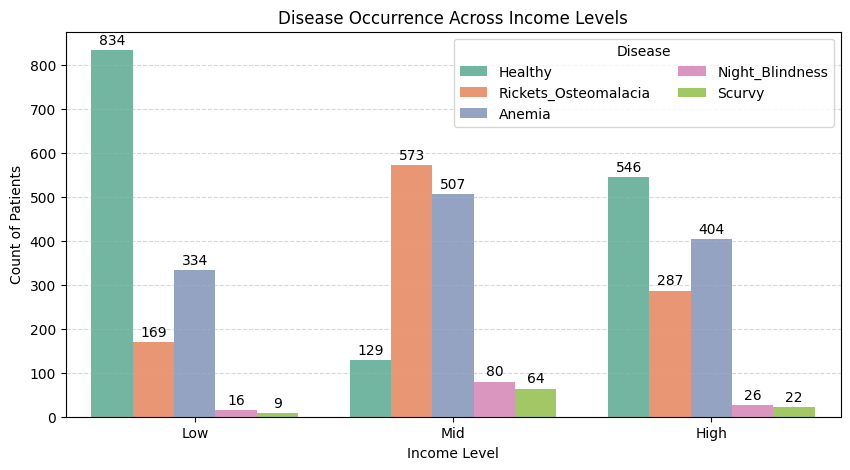

In [30]:
# Q10: Does income level affect disease occurrence?

import matplotlib.pyplot as plt
import seaborn as sns

# Plot disease distribution across income levels
plt.figure(figsize=(10,5))

ax = sns.countplot(
    data=df,
    x='income_level',
    hue='disease_diagnosis',
    palette='Set2'
)

# Add values on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=2)

# Labels
plt.title("Disease Occurrence Across Income Levels")
plt.xlabel("Income Level")
plt.ylabel("Count of Patients")

# Rename encoded labels
plt.xticks(ticks=[0,1,2], labels=['Low', 'Mid', 'High'])
plt.legend(title="Disease",ncol=2)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [31]:
# Income level appears to significantly affect disease occurrence. Low-income individuals have the highest number of healthy cases, 
# while middle-income groups show a much higher occurrence of Anemia and Rickets/Osteomalacia. Night Blindness and Scurvy are also 
# more common in middle-income groups compared to low and high-income groups.

### 11.	Which clinical markers show the highest variation across diseases? 

C:\Users\hp\AppData\Local\Temp\ipykernel_17356\1881182630.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


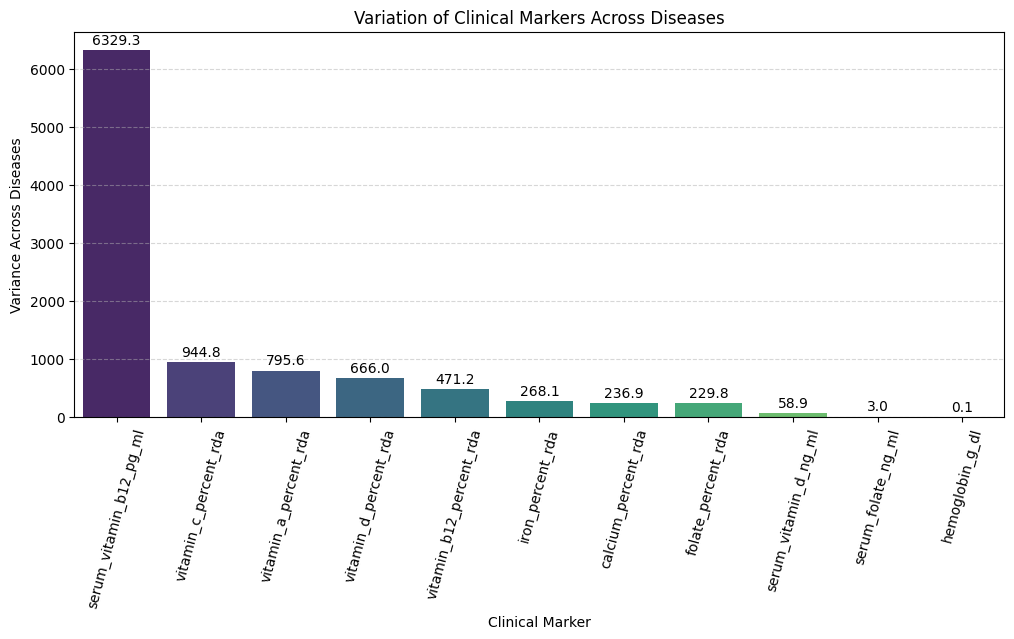

In [32]:
# Q11: Which clinical markers show the highest variation across diseases?

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Select important clinical markers
clinical_markers = [
    'vitamin_a_percent_rda',
    'vitamin_c_percent_rda',
    'vitamin_d_percent_rda',
    'vitamin_b12_percent_rda',
    'folate_percent_rda',
    'calcium_percent_rda',
    'iron_percent_rda',
    'hemoglobin_g_dl',
    'serum_vitamin_d_ng_ml',
    'serum_vitamin_b12_pg_ml',
    'serum_folate_ng_ml'
]

# Calculate variance of each marker across disease groups
variation = df.groupby('disease_diagnosis')[clinical_markers].mean().var().sort_values(ascending=False)

# Convert to DataFrame for plotting
variation_df = variation.reset_index()
variation_df.columns = ['Clinical Marker', 'Variance']

# Plot
plt.figure(figsize=(12,5))
ax = sns.barplot(
    data=variation_df,
    x='Clinical Marker',
    y='Variance',
    palette='viridis'
)

# Add values on top
for i in ax.containers:
    ax.bar_label(i, fmt='%.1f', padding=2)

plt.title("Variation of Clinical Markers Across Diseases")
plt.xlabel("Clinical Marker")
plt.ylabel("Variance Across Diseases")
plt.xticks(rotation=75)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

In [33]:
# To identify which clinical markers differ the most across diseases, variance was used as a statistical measure because it shows how widely 
# the average values of each marker change between different disease groups. Higher variance indicates greater variation across diseases. 
# In this analysis, serum Vitamin B12 showed the highest variation, followed by Vitamin C and Vitamin A, suggesting these markers 
# are the most disease-specific and may play a stronger role in distinguishing different vitamin deficiency conditions.

### 12. What BMI range is most common among healthy individuals? 

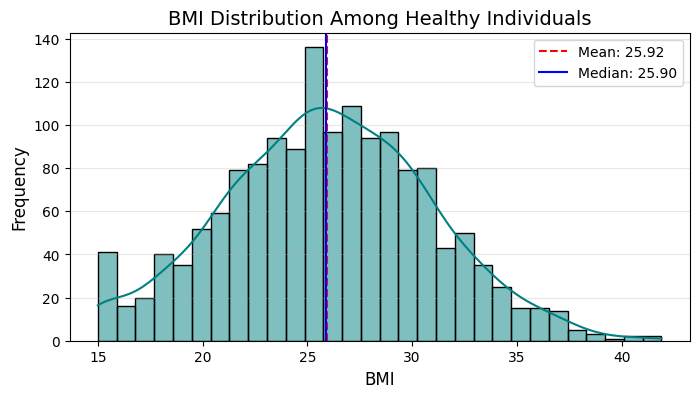

Common BMI Range (IQR): 22.50 to 29.20


In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filtering for healthy individuals
healthy_df = df[df['disease_diagnosis'] == 'Healthy']

plt.figure(figsize=(8, 4))

# Plotting the BMI distribution
sns.histplot(healthy_df['bmi'], kde=True, color='teal', bins=30)

# Highlighting the mean and median
plt.axvline(healthy_df['bmi'].mean(), color='red', linestyle='--', label=f"Mean: {healthy_df['bmi'].mean():.2f}")
plt.axvline(healthy_df['bmi'].median(), color='blue', linestyle='-', label=f"Median: {healthy_df['bmi'].median():.2f}")

plt.title('BMI Distribution Among Healthy Individuals', fontsize=14)
plt.xlabel('BMI', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()

# Calculating the Interquartile Range (IQR) for the "Common Range"
q1 = healthy_df['bmi'].quantile(0.25)
q3 = healthy_df['bmi'].quantile(0.75)
print(f"Common BMI Range (IQR): {q1:.2f} to {q3:.2f}")

In [35]:
# The BMI distribution of healthy individuals is centered around 25–26, with both the mean and median close to 25.9. 
# This indicates that most healthy individuals fall within the normal to slightly overweight BMI range. 
# The near overlap of mean and median also suggests a fairly balanced BMI distribution.

### 13.	Do symptoms like bone pain and fatigue occur together in Rickets patients? 

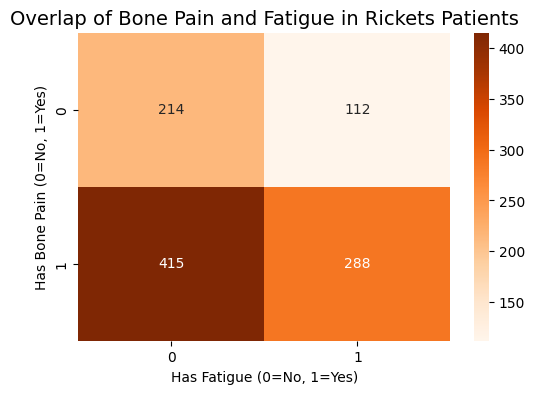

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filtering for Rickets/Osteomalacia patients
rickets_df = df[df['disease_diagnosis'] == 'Rickets_Osteomalacia']

# Creating a contingency table (Crosstab)
symptom_overlap = pd.crosstab(rickets_df['has_bone_pain'], rickets_df['has_fatigue'])

plt.figure(figsize=(6, 4))
sns.heatmap(symptom_overlap, annot=True, fmt='d', cmap='Oranges')

plt.title('Overlap of Bone Pain and Fatigue in Rickets Patients', fontsize=14)
plt.xlabel('Has Fatigue (0=No, 1=Yes)')
plt.ylabel('Has Bone Pain (0=No, 1=Yes)')
plt.show()

In [37]:
# Bone pain is highly common among Rickets patients, while fatigue is less frequent. Many patients experience both bone pain and fatigue 
# together, but the largest group has bone pain without fatigue. This shows that bone pain is the stronger and more dominant 
# symptom in Rickets/Osteomalacia.

### 14.	How does symptoms count vary across different diseases? 

C:\Users\hp\AppData\Local\Temp\ipykernel_17356\3970925563.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


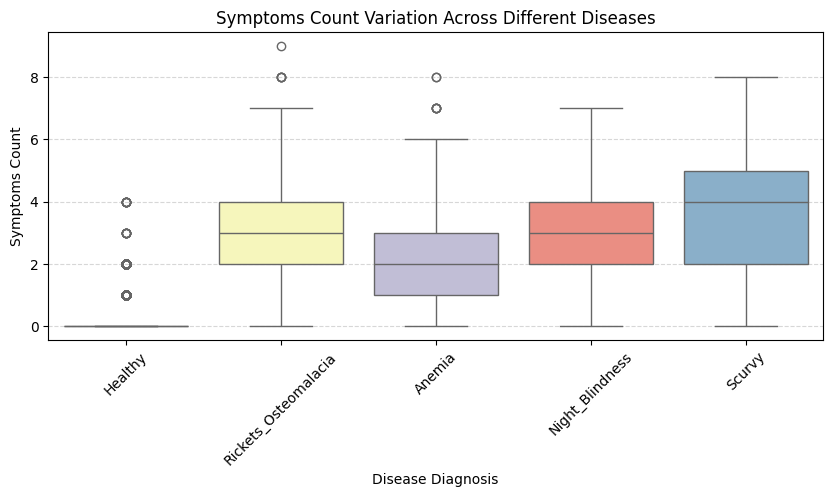

In [38]:
# Q14: How does symptoms count vary across different diseases?

import matplotlib.pyplot as plt
import seaborn as sns

# Plot symptom count distribution across diseases
plt.figure(figsize=(10,4))

ax = sns.boxplot(
    data=df,
    x='disease_diagnosis',
    y='symptoms_count',
    palette='Set3'
)

plt.title("Symptoms Count Variation Across Different Diseases")
plt.xlabel("Disease Diagnosis")
plt.ylabel("Symptoms Count")
plt.xticks(rotation=45)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

In [39]:
# Symptom count varies clearly across diseases. Healthy individuals mostly have zero symptoms, while Scurvy patients show the highest symptom count,
# indicating more severe symptom burden. Rickets/Osteomalacia and Night Blindness also show higher symptom counts than Anemia, 
# suggesting greater symptom complexity.

### 15.	Which vitamin deficiency markers are strongest predictors for each disease category?

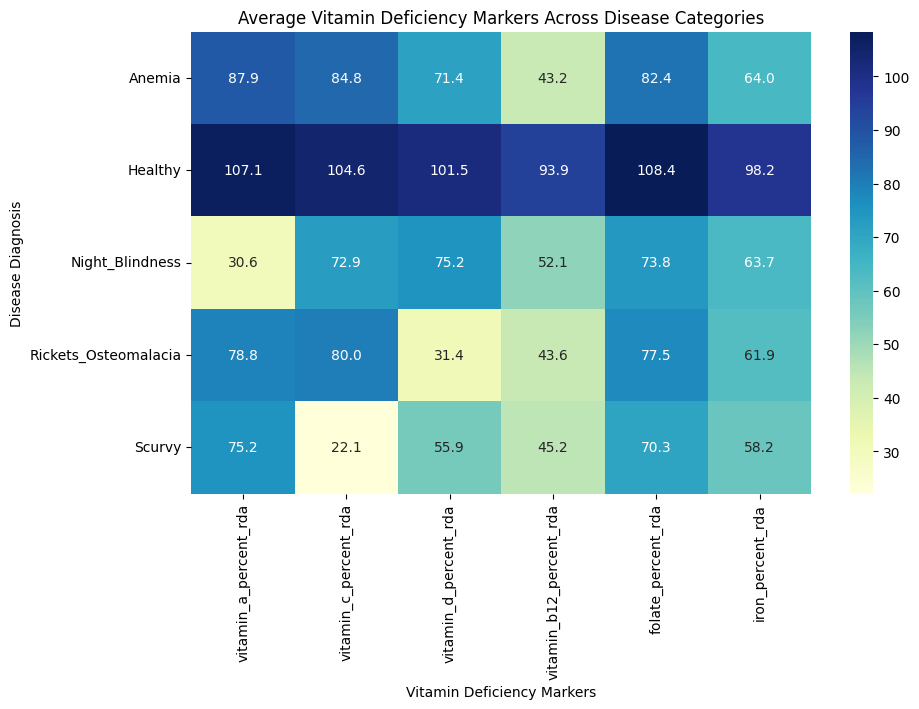

In [40]:
# Q15: Which vitamin deficiency markers are strongest predictors for each disease category?

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Select major vitamin deficiency markers
markers = [
    'vitamin_a_percent_rda',
    'vitamin_c_percent_rda',
    'vitamin_d_percent_rda',
    'vitamin_b12_percent_rda',
    'folate_percent_rda',
    'iron_percent_rda'
]

# Calculate mean marker values for each disease
disease_marker_means = df.groupby('disease_diagnosis')[markers].mean()

# Plot heatmap
plt.figure(figsize=(10,6))

sns.heatmap(
    disease_marker_means,
    annot=True,
    cmap='YlGnBu',
    fmt='.1f'
)

plt.title("Average Vitamin Deficiency Markers Across Disease Categories")
plt.xlabel("Vitamin Deficiency Markers")
plt.ylabel("Disease Diagnosis")

plt.show()

In [41]:
# Each disease category is linked to specific nutrient deficiencies. Night Blindness is mainly associated with low
# Vitamin A, Scurvy with very low Vitamin C, Rickets/Osteomalacia with low Vitamin D, and Anemia with lower Iron levels. 
# These clear deficiency patterns show that vitamin and mineral markers are strong predictors for identifying different diseases.

### 16.	Do hemoglobin levels significantly differ across disease categories?

In [ ]:
# To determine whether hemoglobin levels differ significantly across multiple disease categories, ANOVA (Analysis of Variance) is used.
# ANOVA compares the mean hemoglobin levels of all disease groups and checks whether the observed differences are statistically significant.

ANOVA F-Statistic: 32.52085253309417
P-Value: 1.020950204134747e-26


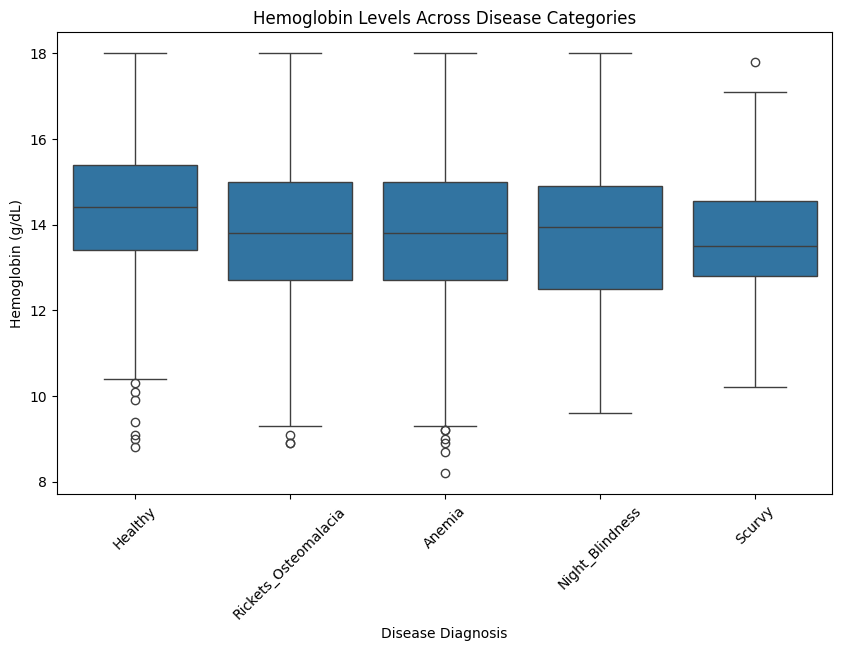

In [49]:
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# Create groups
healthy = df[df['disease_diagnosis'] == 'Healthy']['hemoglobin_g_dl']
anemia = df[df['disease_diagnosis'] == 'Anemia']['hemoglobin_g_dl']
night_blindness = df[df['disease_diagnosis'] == 'Night_Blindness']['hemoglobin_g_dl']
rickets = df[df['disease_diagnosis'] == 'Rickets_Osteomalacia']['hemoglobin_g_dl']
scurvy = df[df['disease_diagnosis'] == 'Scurvy']['hemoglobin_g_dl']

# ANOVA
f_stat, p_value = stats.f_oneway(healthy, anemia, night_blindness, rickets, scurvy)

print("ANOVA F-Statistic:", f_stat)
print("P-Value:", p_value)

# Plot
plt.figure(figsize=(10,6))
sns.boxplot(x='disease_diagnosis', y='hemoglobin_g_dl', data=df)

plt.title('Hemoglobin Levels Across Disease Categories')
plt.xlabel('Disease Diagnosis')
plt.ylabel('Hemoglobin (g/dL)')

plt.xticks(rotation=45)
plt.show()

In [ ]:
# The ANOVA test produced a very small p-value (p < 0.001), indicating a significant difference in hemoglobin levels across disease categories. 
# The boxplot shows that healthy individuals generally have slightly higher hemoglobin levels, while disease groups such as Anemia and Scurvy 
# tend to show relatively lower levels. This suggests that hemoglobin is an important clinical marker and may contribute to distinguishing 
# between different disease conditions.